# 04 · Building the self-organizing map

**Goal.** Classify the selected days into a small number of recurring 850 hPa flow patterns,
composite the physical fields within each class, and test how much of the result depends on
choices we made rather than on the atmosphere.

## What a SOM does, and why use one here

A self-organizing map is an unsupervised neural network that projects high-dimensional data onto
a low-dimensional (here 2-D) grid of **nodes**, while preserving *topology*: nodes that end up
adjacent on the grid hold similar patterns. Each day is assigned to its **best-matching unit**
(BMU), the node whose weight vector is closest in Euclidean distance.

The method entered synoptic climatology through **Hewitson & Crane (2002)**, and
**Sheridan & Lee (2011)** is the standard methods review. Their argument for SOM over PCA/EOF
decomposition is the one that applies here: SOM training is iterative and non-linear, so it can
represent a *continuum* of circulation states, whereas EOFs are restricted to orthogonal linear
combinations. Atmospheric flow regimes are not orthogonal, and the leading EOF of a wind field
is often a pattern no individual day actually resembles.

The trade-off is honest: a SOM has no variance-explained decomposition and no significance test.
It is a *classification* tool, and its output is only as good as the choices documented below.

## Vector wind, not wind speed

The SOM is trained on **u and v components**, standardized per grid cell and concatenated into
one feature vector per day:

$$\mathbf{x}_d = \left[\; \tilde{u}_d(\text{all cells}) \;\Vert\; \tilde{v}_d(\text{all cells}) \;\right],
\qquad \tilde{u} = \frac{u - \bar{u}}{\sigma_u}$$

This matters. Training on scalar wind **speed** would make the distance metric blind to
direction, and the classification would reduce to "windy vs. calm days" — discarding precisely
the onshore/offshore and cross-equatorial distinctions that control moisture delivery to the
coast. Speed appears later only as a *plotting* variable, shading beneath the composite vectors.

## Per-cell standardization

Each grid cell's `u` and `v` are z-scored across the sample before concatenation. Rationale:
`u` and `v` have different variances, and both vary by more than an order of magnitude between
the quiet equatorial interior and the strong offshore flow. Without standardization the distance
metric is dominated by the few highest-variance cells and the classification effectively ignores
most of the domain.

Note this departs from the common convention in synoptic climatology, where SOMs are often
trained on raw or anomaly fields of a *single* variable (SLP, geopotential height) that is
already on one physical scale. Standardization earns its place here because we are mixing two
components with different statistics.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from minisom import MiniSom

import sys
sys.path.append("../src")
from config import DATA_DIR, FIG_DIR, SOM_PARAMS, NWSA_EXTENT

wind = xr.open_dataset(DATA_DIR / "era5_850_wind_heavy_enso.nc")
days = pd.read_csv(DATA_DIR / "heavy_enso_positive_days.csv", parse_dates=["date"])
terrain_mask = np.load(DATA_DIR / "terrain_mask_1500m.npy")

print(wind.sizes)
print(SOM_PARAMS)

Frozen({'time': 137, 'latitude': 141, 'longitude': 141})
{'sigma': 1.0, 'learning_rate': 0.5, 'random_seed': 42, 'neighborhood_function': 'gaussian', 'n_iterations': 8000}


## 1. Align the day metadata to the wind file's time axis

A step that is easy to get wrong and silently poisons everything downstream. The wind file's
time axis and the day-list CSV must be matched **by date**, not assumed to be in the same order.
If a day was skipped during retrieval, positional alignment would shift every subsequent label
by one — producing a plausible-looking but entirely wrong classification.

Assert the date *sets* match, then reindex explicitly.

In [2]:
wind_dates = pd.to_datetime(wind.time.values).normalize()
day_dates = days["date"].dt.normalize()

assert set(wind_dates) == set(day_dates), (
    f"date sets differ: {len(set(day_dates) - set(wind_dates))} days missing from wind file"
)

meta = days.set_index(day_dates).loc[wind_dates].reset_index(drop=True)
print("aligned:", len(meta), "days")

aligned: 137 days


## 2. Build the feature matrix

In [3]:
def build_features(u, v):
    """Per-cell z-score of u and v, flattened and concatenated -> (n_days, 2*ny*nx)."""
    def z(a):
        m, s = a.mean(axis=0), a.std(axis=0)
        s = np.where(s == 0, 1.0, s)      # guard against constant cells
        return (a - m) / s
    n = u.shape[0]
    return np.concatenate([z(u).reshape(n, -1), z(v).reshape(n, -1)], axis=1).astype("float64")

U, V = wind.u850.values, wind.v850.values
X = build_features(U, V)

print("feature matrix:", X.shape, f"({X.shape[1]:,} features = 2 x {U.shape[1]} x {U.shape[2]})")
assert np.isfinite(X).all(), "non-finite values in feature matrix"
print("n_days / n_features ratio: %.4f  <- heavily underdetermined, by design" % (X.shape[0] / X.shape[1]))

feature matrix: (137, 39762) (39,762 features = 2 x 141 x 141)
n_days / n_features ratio: 0.0034  <- heavily underdetermined, by design


That ratio deserves a comment. With ~100 days and ~40,000 features the problem is extremely
underdetermined in a regression sense. This is normal and acceptable for SOM circulation typing —
the SOM is not fitting a predictive model, it is partitioning samples by similarity, and the
high dimensionality is spatially smooth (neighbouring cells are highly correlated), so the
*effective* dimensionality is far lower than the nominal feature count.

## 3. Train

Grid size **3×3 = 9 nodes**. Justification, in order of weight:

1. **Sample size.** ~100 days over 9 nodes averages ~15 days/node. A 4×4 grid would average ~8,
   and the smallest nodes would become uninterpretable.
2. **Convention.** 9 nodes sits squarely in the range used in the synoptic-SOM literature
   (typically 6–12 for regional circulation typing).
3. **Diagnostics.** Section 6 measures it rather than asserting it.

`sigma` (neighbourhood width) and `learning_rate` are minisom defaults-ish values that are
standard in this literature; `random_seed` is fixed because SOM training is stochastic and an
unseeded run is not reproducible.

In [4]:
def train_som(X, grid=(3, 3), **kw):
    p = {**SOM_PARAMS, **kw}
    som = MiniSom(grid[0], grid[1], X.shape[1],
                  sigma=p["sigma"], learning_rate=p["learning_rate"],
                  random_seed=p["random_seed"], neighborhood_function=p["neighborhood_function"])
    som.random_weights_init(X)
    som.train_random(X, num_iteration=p["n_iterations"])
    bmus = np.array([som.winner(x) for x in X])
    node_id = bmus[:, 0] * grid[1] + bmus[:, 1]      # row-major flattening -> node 0..8
    return som, node_id

som, node_id = train_som(X, grid=(3, 3))
meta["som_node"] = node_id

counts = np.bincount(node_id, minlength=9)
print("days per node:")
print(counts.reshape(3, 3))
print("\ntotal:", counts.sum(), " min:", counts.min(), " max:", counts.max())

days per node:
[[ 4 26  9]
 [13 18  8]
 [20 27 12]]

total: 137  min: 4  max: 27


> **Small-node warning.** Any node with n ≲ 5 is one or two weather events, not a regime.
> Its composite will look sharp and convincing and mean almost nothing. Every figure below is
> labelled with `n` so the reader can discount those panels, and the summary table reports `n`
> alongside every statistic.

## 4. Node composites — of the physical field, not the weights

A distinction that is easy to get wrong: we composite the **actual, un-standardized wind** of
the days assigned to each node. We do *not* plot the SOM's internal weight vectors.

The weights live in z-score space and are shaped by the training trajectory; the composite of
real days is a physical field in m/s that you can interpret and compare to other datasets.

In [5]:
def node_composites(field_u, field_v, node_id, n_nodes=9):
    ny, nx = field_u.shape[1:]
    cu = np.zeros((n_nodes, ny, nx))
    cv = np.zeros((n_nodes, ny, nx))
    for k in range(n_nodes):
        m = node_id == k
        cu[k] = field_u[m].mean(axis=0)
        cv[k] = field_v[m].mean(axis=0)
    return cu, cv

node_u, node_v = node_composites(U, V, node_id)
node_spd = np.sqrt(node_u**2 + node_v**2)

print("composite speed range: %.2f to %.2f m/s" % (node_spd.min(), node_spd.max()))
print("\nper-node domain-mean speed (m/s), terrain-masked:")
for k in range(9):
    s = np.where(terrain_mask, np.nan, node_spd[k])
    print(f"  node {k} (n={counts[k]:2d}): {np.nanmean(s):5.2f}")

composite speed range: 0.00 to 19.99 m/s

per-node domain-mean speed (m/s), terrain-masked:
  node 0 (n= 4):  4.54
  node 1 (n=26):  4.46
  node 2 (n= 9):  6.48
  node 3 (n=13):  5.28
  node 4 (n=18):  5.66
  node 5 (n= 8):  3.38
  node 6 (n=20):  3.48
  node 7 (n=27):  4.57
  node 8 (n=12):  3.20


In [6]:
# attach the precipitation / ENSO statistics that make each node interpretable
node_summary = (meta.assign(is_super=lambda d: d.phase == "super_el_nino")
                .groupby("som_node")
                .agg(n_days=("date", "count"),
                     mean_precip_mm=("mean_mm", "mean"),
                     mean_nino12_anom=("nino12_anom", "mean"),
                     pct_super_el_nino=("is_super", lambda s: 100 * s.mean()))
                .reindex(range(9)).round(2))
node_summary["mean_speed_ms"] = [round(float(np.nanmean(np.where(terrain_mask, np.nan, node_spd[k]))), 2)
                                 for k in range(9)]
print(node_summary.to_string())

          n_days  mean_precip_mm  mean_nino12_anom  pct_super_el_nino  mean_speed_ms
som_node                                                                            
0              4           61.66              1.84              50.00           4.54
1             26           72.02              1.43              15.38           4.46
2              9           82.25              0.86               0.00           6.48
3             13           58.50              1.35              15.38           5.28
4             18           57.01              1.18               5.56           5.66
5              8           64.03              2.03              75.00           3.38
6             20           57.81              1.59              40.00           3.48
7             27           50.09              1.51              25.93           4.57
8             12           49.04              1.67              58.33           3.20


**How to read this table.** The columns are deliberately side by side because the interesting
result is where they *fail* to line up. A node can have the highest mean precipitation while
having the *lowest* fraction of super-El-Niño days — which says the flow pattern, not the SST
anomaly magnitude, is what delivered the rain that day. Check that in your own run: rank the
nodes by `mean_precip_mm` and by `pct_super_el_nino` and see whether the orderings agree.

## 5. The composite figure

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from config import PROVINCES_GPKG

def plot_node_grid(cu, cv, counts, terrain_mask, lon, lat, *,
                   cmap="Spectral_r", vmax=20, step=6, title="", subtitle="",
                   annot=None, outfile=None):
    proj = ccrs.PlateCarree()
    lon2d, lat2d = np.meshgrid(lon, lat)
    prov = gpd.read_file(PROVINCES_GPKG)
    norm = mpl.colors.Normalize(0, vmax)
    cm = plt.get_cmap(cmap)

    fig, axes = plt.subplots(3, 3, figsize=(10.5, 12.3), subplot_kw=dict(projection=proj),
                             gridspec_kw=dict(wspace=0.05, hspace=0.16))
    for k in range(9):
        ax = axes[k // 3, k % 3]
        ax.set_extent(NWSA_EXTENT, crs=proj)
        spd = np.sqrt(cu[k]**2 + cv[k]**2)
        # mask where 850 hPa is at/below ground (see notebook 03)
        ax.pcolormesh(lon2d, lat2d, np.where(terrain_mask, np.nan, spd),
                      cmap=cm, norm=norm, transform=proj, rasterized=True, shading="auto")
        ax.pcolormesh(lon2d, lat2d, np.where(terrain_mask, 1.0, np.nan),
                      cmap=mpl.colors.ListedColormap(["0.55"]), transform=proj,
                      rasterized=True, shading="auto")
        ax.quiver(lon2d[::step, ::step], lat2d[::step, ::step],
                  np.where(terrain_mask, np.nan, cu[k])[::step, ::step],
                  np.where(terrain_mask, np.nan, cv[k])[::step, ::step],
                  transform=proj, scale=220, width=0.0035, color="0.1")
        ax.coastlines(resolution="10m", linewidth=0.5, color="0.15")
        ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.4, color="0.15")
        prov.boundary.plot(ax=ax, linewidth=0.4, edgecolor="0.85", transform=proj)
        ax.set_title(f"Node {k}  (n={counts[k]})", fontsize=9.5, pad=3)
        if annot is not None:
            ax.text(0.02, 0.02, annot[k], transform=ax.transAxes, fontsize=6.5,
                    va="bottom", ha="left", color="white",
                    bbox=dict(facecolor="0.15", alpha=0.75, pad=2, edgecolor="none"))
        ax.set_xticks([]); ax.set_yticks([])

    cax = fig.add_axes([0.3, 0.045, 0.4, 0.014])
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cm), cax=cax,
                      orientation="horizontal", extend="max")
    cb.set_label("850 hPa wind speed (m/s)", fontsize=8.5, labelpad=6)
    cb.ax.tick_params(labelsize=7)
    fig.suptitle(title, fontsize=13, fontweight="bold", y=0.99)
    fig.text(0.5, 0.945, subtitle, ha="center", fontsize=8.5, color="0.3")
    fig.subplots_adjust(left=0.02, right=0.98, top=0.905, bottom=0.085)
    if outfile:
        fig.savefig(outfile, dpi=200)
    return fig

/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolo

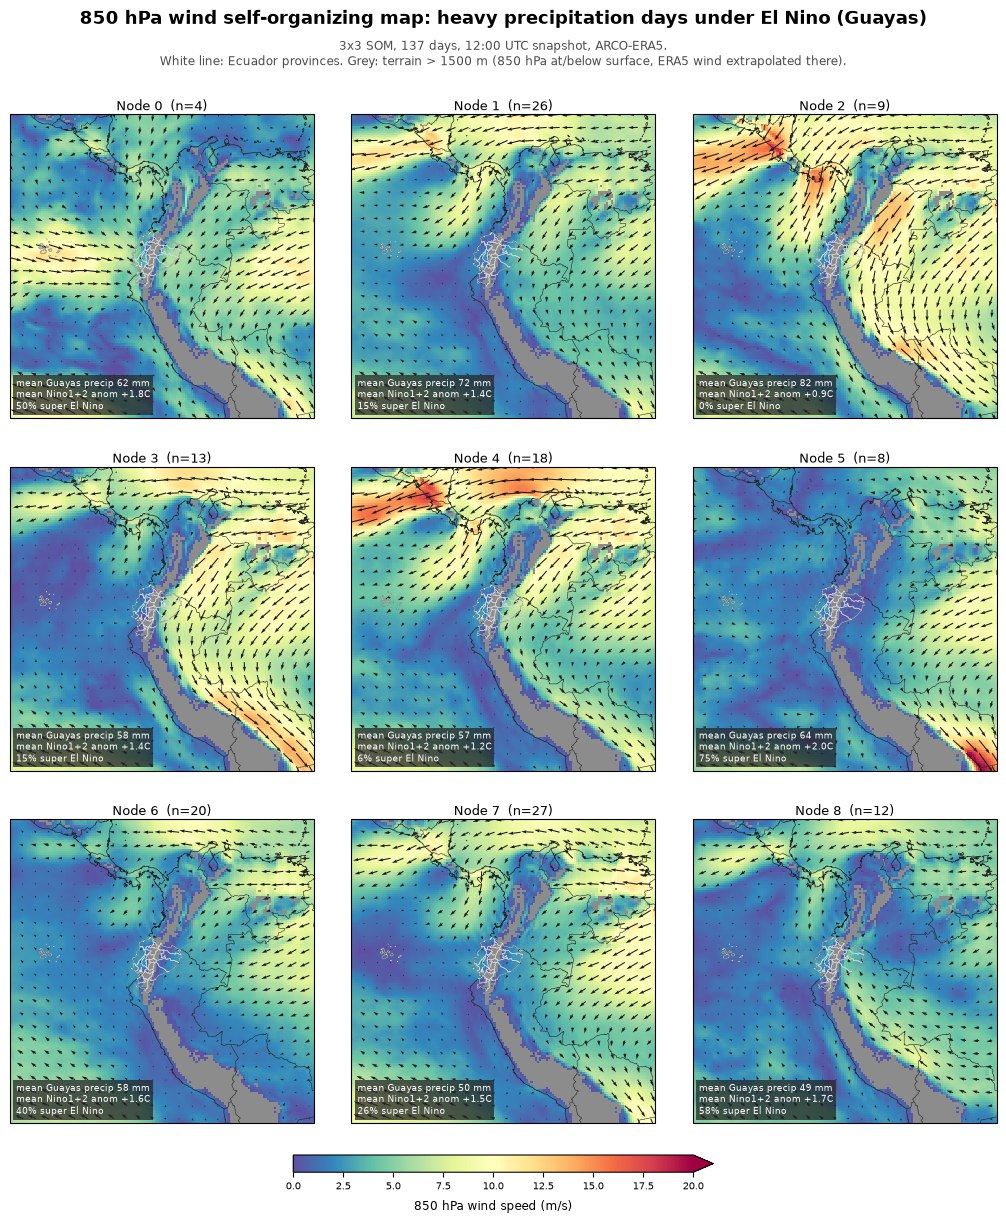

In [8]:
annot = [f"mean Guayas precip {node_summary.mean_precip_mm[k]:.0f} mm\n"
         f"mean Nino1+2 anom +{node_summary.mean_nino12_anom[k]:.1f}C\n"
         f"{node_summary.pct_super_el_nino[k]:.0f}% super El Nino" for k in range(9)]

fig = plot_node_grid(
    node_u, node_v, counts, terrain_mask,
    wind.longitude.values - 360, wind.latitude.values,
    title="850 hPa wind self-organizing map: heavy precipitation days under El Nino (Guayas)",
    subtitle=("3x3 SOM, %d days, 12:00 UTC snapshot, ARCO-ERA5.\n"
              "White line: Ecuador provinces. Grey: terrain > 1500 m "
              "(850 hPa at/below surface, ERA5 wind extrapolated there)." % len(meta)),
    annot=annot, outfile=FIG_DIR / "som_wind_nodes.png")

## 6. Diagnostics: is 3×3 actually the right size?

The standard SOM quality metrics, and the one methodological gap in most published tropical-SOM
studies (they usually pick a grid size a priori without reporting either):

- **Quantization error (QE)** — mean Euclidean distance from each sample to its BMU. Measures how
  well the map *represents* the data. **QE always decreases as nodes are added**, so it cannot be
  used alone to choose a size: taken to its limit, one node per day gives QE = 0 and no
  classification at all.
- **Topographic error (TE)** — fraction of samples whose best and *second*-best matching units are
  not adjacent on the grid. Measures whether the map's topology actually reflects the data's
  structure. Unlike QE, it does not trivially improve with size.

Use them together, and against the sample-size constraint from section 3.

In [9]:
def qe_te(som, X):
    w = som.get_weights()
    qe = float(np.mean([np.linalg.norm(x - w[som.winner(x)]) for x in X]))
    te = float(som.topographic_error(X))
    return qe, te

rows = []
for grid in [(2, 2), (3, 3), (4, 4)]:
    s_, nid_ = train_som(X, grid=grid)
    q, t = qe_te(s_, X)
    c_ = np.bincount(nid_, minlength=grid[0]*grid[1])
    rows.append({"grid": f"{grid[0]}x{grid[1]}", "n_nodes": grid[0]*grid[1],
                 "QE": round(q, 2), "TE": round(t, 3),
                 "min_node_n": int(c_.min()), "median_node_n": int(np.median(c_))})

print(pd.DataFrame(rows).to_string(index=False))

grid  n_nodes     QE    TE  min_node_n  median_node_n
 2x2        4 185.84 0.000          22             32
 3x3        9 174.83 0.423           4             13
 4x4       16 162.42 0.270           2              8


Read the table as a trade-off, not a winner — and note that **it does not vindicate 3×3**.

- **QE falls monotonically** with node count (186 → 175 → 162), exactly as predicted. It
  contributes nothing to the choice on its own.
- **TE for the 2×2 grid is 0.000, which is an artifact, not a triumph.** On a 2×2 map every node
  is adjacent to every other node, so the "best and second-best units are neighbours" condition
  is satisfied trivially. TE is only informative for grids large enough to have non-adjacent
  nodes.
- Between the two grids where TE *is* meaningful, **4×4 scores better than 3×3** (0.270 vs
  0.423). Topology preservation alone would pick the larger map.
- But 4×4 drives `min_node_n` to **2**. A two-day composite is a pair of weather events; it will
  look sharp and mean nothing.

So the honest statement is: **3×3 is chosen on sample-size grounds despite worse topology
preservation than 4×4**, not because the diagnostics favour it. With ~137 days there is no grid
size that is good on both axes — that is a limitation of the sample, and the fix is more days
(see notebook 02, section 5), not a different grid.

This is exactly why the diagnostics are worth computing even when they do not endorse your
choice: without them, "3×3, consistent with the literature" would have read as a justification
rather than a compromise.

In [10]:
from sklearn.metrics import adjusted_mutual_info_score, normalized_mutual_info_score

GYE_LAT, GYE_LON = -2.1894, -79.8891
HALF = 35.0 / 4                                   # half of the original half-span

lon180 = wind.longitude.values - 360
lat_v = wind.latitude.values
lat_sel = (lat_v >= GYE_LAT - HALF) & (lat_v <= GYE_LAT + HALF)
lon_sel = (lon180 >= GYE_LON - HALF) & (lon180 <= GYE_LON + HALF)

sub = wind.isel(latitude=lat_sel, longitude=lon_sel)
X_sub = build_features(sub.u850.values, sub.v850.values)
som_sub, node_id_sub = train_som(X_sub, grid=(3, 3))

q1, t1 = qe_te(som, X)
q2, t2 = qe_te(som_sub, X_sub)

print("domain            grid        features      QE      TE")
print(f"full NWSA        {U.shape[1]}x{U.shape[2]}    {X.shape[1]:7,}   {q1:7.2f}  {t1:.3f}")
print(f"Guayaquil half   {sub.sizes['latitude']}x{sub.sizes['longitude']}      "
      f"{X_sub.shape[1]:7,}   {q2:7.2f}  {t2:.3f}")
print()
print("AMI  (chance-corrected):", round(adjusted_mutual_info_score(node_id, node_id_sub), 3))
print("NMI                    :", round(normalized_mutual_info_score(node_id, node_id_sub), 3))

domain            grid        features      QE      TE
full NWSA        141x141     39,762    174.83  0.423
Guayaquil half   70x70        9,800     80.90  0.299

AMI  (chance-corrected): 0.304
NMI                    : 0.393


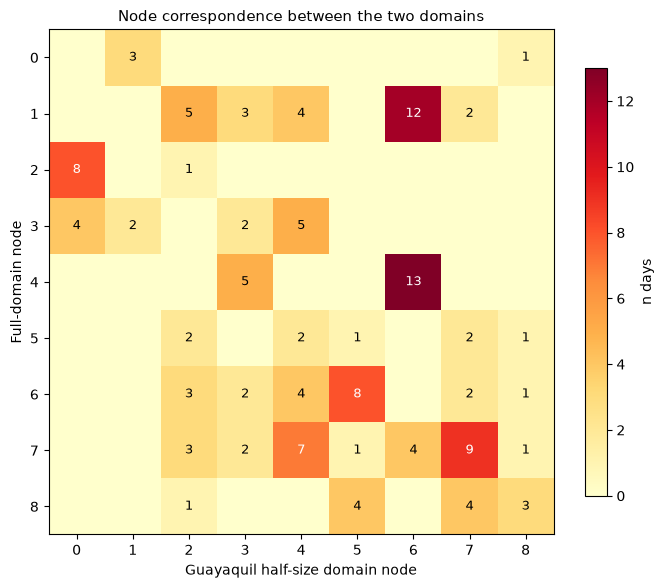

In [11]:
ct = pd.crosstab(pd.Series(node_id, name="full-domain node"),
                 pd.Series(node_id_sub, name="Guayaquil half-size node"))
ct = ct.reindex(index=range(9), columns=range(9), fill_value=0)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(ct.values, cmap="YlOrRd")
for i in range(9):
    for j in range(9):
        v = ct.values[i, j]
        if v:
            ax.text(j, i, v, ha="center", va="center", fontsize=9,
                    color="white" if v > ct.values.max() * 0.5 else "black")
ax.set_xticks(range(9)); ax.set_yticks(range(9))
ax.set_xlabel("Guayaquil half-size domain node")
ax.set_ylabel("Full-domain node")
ax.set_title("Node correspondence between the two domains", fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.8, label="n days")
fig.tight_layout()
fig.savefig(FIG_DIR / "som_domain_sensitivity.png", dpi=200)

**Interpreting the sensitivity result.** Both QE and TE drop for the smaller domain — but that
is largely mechanical: QE scales with the number of input dimensions, and a smaller, more
spatially coherent field is easier to organize topologically. **Lower QE/TE here does not mean
the smaller domain is a better classification.**

The informative number is the AMI. Moderate agreement (well above chance, well below identity)
means the two domains are finding *partly* the same structure. Nodes that survive the narrowing
are defined by local flow; nodes that fragment were being separated by large-scale features
outside the small window — cross-equatorial flow, the Amazon-side circulation, the position of
the Pacific moisture band. Those features are doing real classificatory work.

Practical upshot: **report the domain, and don't shrink it to the region of interest** unless
you have checked that the classification survives.

## 8. Save

In [12]:
out = meta[["date", "mean_mm", "max_mm", "nino12_anom", "phase", "som_node"]].copy()
out["som_node_guayaquil_half"] = node_id_sub
out.to_csv(DATA_DIR / "som_node_assignments.csv", index=False)
node_summary.to_csv(DATA_DIR / "som_node_summary.csv")
np.savez(DATA_DIR / "som_node_composites_wind.npz",
         node_u=node_u, node_v=node_v,
         latitude=wind.latitude.values, longitude=wind.longitude.values)

pd.DataFrame(rows).to_csv(DATA_DIR / "som_grid_diagnostics.csv", index=False)
print("saved node assignments, summary, composites, and diagnostics")

saved node assignments, summary, composites, and diagnostics


## What notebook 05 needs from here

- `data/som_node_assignments.csv` — the `date` → `som_node` mapping
- `data/terrain_mask_1500m.npy` — reused for the same masking decision

## Extending this

The node labels are now just a categorical variable on dates, so **any** daily field can be
composited by node with the same three lines: align by date, group by `som_node`, average.
Notebook 05 does this for vapor transport. The same pattern gives you node composites of
precipitation (from notebook 01's stores), soil moisture, or an external index — the MJO phase
distribution per node is a one-line `pd.crosstab` once you have a daily MJO index joined on
`date`.